In [78]:
import argparse
import matplotlib.pyplot as plt
import mujoco
import mujoco.viewer
import numpy as np
import os
from pathlib import Path
import time
from scipy import linalg
import cvxpy as cp
from scipy.linalg import eigh

In [79]:
# Configure MuJoCo to use the EGL rendering backend (requires GPU)
os.environ["MUJOCO_GL"] = "egl"


model_name = f"helix_control"

# Cartesian impedance control gains.
impedance_pos = np.asarray([50.0, 50.0, 50.0])  # [N/m]
impedance_ori = np.asarray([50.0, 50.0, 50.0])  # [Nm/rad]

# Joint impedance control gains.


# Damping ratio for both Cartesian and joint impedance control.
damping_ratio = 1.0

# Gains for the twist computation. These should be between 0 and 1. 0 means no
# movement, 1 means move the end-effector to the target in one integration step.
Kpos: float = 0.95

# Gain for the orientation component of the twist computation. This should be
# between 0 and 1. 0 means no movement, 1 means move the end-effector to the target
# orientation in one integration step.
Kori: float = 0.95
stiffness = 0.01


f_ctrl = 2000.0 
T = 1
w = 2 * np.pi / T

B = np.zeros((36, 9))
for i in range(3):  # Iterate over u1, u2, u3 blocks
    for j in range(4):  # Repeat each block 4 times
        row_start = i * 12 + j * 3  # Compute row index
        col_start = i * 3  # Compute column index
        B[row_start:row_start+3, col_start:col_start+3] = np.eye(3)  # Assign identity

print(B)


[[1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [1. 0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 1. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 1. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0. 1.]
 [0. 0. 0.

In [80]:
def get_coriolis_and_gravity(model, data):
    """
    Calculate the Coriolis matrix and gravity vector for a MuJoCo model

    Parameters:
        model: MuJoCo model object
        data: MuJoCo data object

    Returns:
        C: Coriolis matrix (nv x nv)
        g: Gravity vector (nv,)
    """
    nv = model.nv  # number of degrees of freedom

    # Calculate gravity vector
    g = np.zeros(nv)
    dummy = np.zeros(nv,)
    mujoco.mj_factorM(model, data)  # Compute sparse M factorization
    mujoco.mj_rne(model, data, 0, dummy)  # Run RNE with zero acceleration and velocity
    g = data.qfrc_bias.copy()

    # Calculate Coriolis matrix
    C = np.zeros((nv, nv))
    q_vel = data.qvel.copy()

    # Compute each column of C using finite differences
    eps = 1e-6
    for i in range(nv):
        # Save current state
        vel_orig = q_vel.copy()

        # Perturb velocity
        q_vel[i] += eps
        data.qvel = q_vel

        # Calculate forces with perturbed velocity
        mujoco.mj_rne(model, data, 0, dummy)
        tau_plus = data.qfrc_bias.copy()

        # Restore original velocity
        q_vel = vel_orig
        data.qvel = q_vel

        # Compute column of C using finite difference
        C[:, i] = (tau_plus - data.qfrc_bias) / eps

    return C, g

In [81]:
def compute_jacobian_derivative(model, data, site_id, h=1e-6):
    """
    Compute the time derivative of the Jacobian in MuJoCo.
    
    Parameters:
    - model: The MuJoCo model (mjModel).
    - data: The MuJoCo data structure (mjData).
    - jac_func: Function to compute the Jacobian (e.g., mj_jacBody or mj_jacSite).
    - h: Small positive step for numerical differentiation.
    
    Returns:
    - Jdot: The time derivative of the Jacobian.
    """
    # Step 1: Update kinematics
    mujoco.mj_kinematics(model, data)
    mujoco.mj_comPos(model, data)
    
    # Step 2: Compute the initial Jacobian
    J = np.zeros((6, model.nv))  # Assuming a 6xnv Jacobian for full spatial representation
    mujoco.mj_jacSite(model, data, J[:3], J[3:], site_id)
    
    # Step 3: Integrate position using velocity
    qpos_backup = np.copy(data.qpos)  # Backup original qpos
    mujoco.mj_integratePos(model, data.qpos, data.qvel, h)
    
    # Step 4: Update kinematics again
    mujoco.mj_kinematics(model, data)
    mujoco.mj_comPos(model, data)
    
    # Step 5: Compute the new Jacobian
    Jh = np.zeros((6, model.nv))
    mujoco.mj_jacSite(model, data, Jh[:3], Jh[3:], site_id)
    
    # Step 6: Compute Jdot
    Jdot = (Jh - J) / h
    
    # Step 7: Restore qpos
    data.qpos[:] = qpos_backup
    
    return Jdot

In [82]:
def controller(model, data):
    jac = np.zeros((6, model.nv))
    twist = np.zeros(6)
    site_quat = np.zeros(4)
    site_quat_conj = np.zeros(4)
    error_quat = np.zeros(4)
    M_inv = np.zeros((model.nv, model.nv))
    M = np.zeros((model.nv, model.nv))
    Kp_null = np.asarray([1] * model.nv)

    mocap_name = "target"
    mocap_id = model.body(mocap_name).mocapid[0]

    Kd_null = damping_ratio * 2 * np.sqrt(Kp_null)
    n = 6
    F = np.zeros((2*n,2*n))
    m = 6
    F = np.zeros((2*m,2*m))
    F[:m,m:] = np.eye(m,m)
    G = np.zeros((2*m,m))
    G[m:,:] = np.eye(m)
    e = 0.05
    Pe = linalg.block_diag(np.eye(m) / e, np.eye(m) ).T @ linalg.solve_continuous_are(F, G, np.eye(2*m), np.eye(m)) @ linalg.block_diag(np.eye(m) / e, np.eye(m) )
    

    pinv_B = np.linalg.pinv(B)
    site_name = "ee"
    site_id = model.site(site_name).id
    # data.mocap_pos[mocap_id] = np.array([0.23312815, -0.31631513, 0.44791383])
    data.mocap_pos[mocap_id] = np.array([0.27083678, 0.00194196, 0.38488434])
    dx = data.mocap_pos[mocap_id] - data.site(site_id).xpos
    twist[:3] = dx 
    mujoco.mju_mat2Quat(site_quat, data.site(site_id).xmat)
    mujoco.mju_negQuat(site_quat_conj, site_quat)
    mujoco.mju_mulQuat(error_quat, data.mocap_quat[mocap_id], site_quat_conj)
    mujoco.mju_quat2Vel(twist[3:], error_quat, 1.0)
    twist[3:] *= Kori 

    q = data.qpos
    mujoco.mj_kinematics(model,data)
    mujoco.mj_comPos(model,data)
    mujoco.mj_jacSite(model, data, jac[:3], jac[3:], site_id)
    
    # Compute the task-space inertia matrix.
    mujoco.mj_solveM(model, data, M_inv, np.eye(model.nv))
    mujoco.mj_fullM(model, M, data.qM)
    M = M * np.random.normal(1.0, 0.01, size=M.shape)  # Add some noise to the inertia matrix
    dJ_dt = compute_jacobian_derivative(model, data, site_id)

    Mx_inv = jac @ M_inv @ jac.T
    e = e
    if abs(np.linalg.det(Mx_inv)) >= 1e-2:
        Mx = np.linalg.inv(Mx_inv)
    else:
        Mx = np.linalg.pinv(Mx_inv, rcond=1e-2)

    Jbar = M_inv @ jac.T @ Mx

    # define decision variables
    nu = 9
    nq = model.nq
    u = cp.Variable(shape=(nu, 1))
    qdd = cp.Variable(shape=(nq, 1))
    dl = cp.Variable(shape=(1, 1))
    mu = cp.Variable(shape=(6, 1))
    twist[3:] = 0.0

    # error and Lyapunov function for CLF
    eta = np.concatenate((-twist,jac @ data.qvel))
    V = eta.T @ Pe @ eta

    C, g = get_coriolis_and_gravity(model, data)

    # static forces
    statics = (g + data.qfrc_spring)
    dq = data.qvel.reshape(-1,1)
    stat = cp.square(cp.norm(B @ u - statics.reshape(-1,1)))

    # selection matrix for compression/extension actuators
    sel = np.ones((nu,1))
    sel[[2,5,8]] = 0.0

    # nullspace projection
    ddq = Kp_null * (- data.qpos) - 4*Kd_null * data.qvel
    null = 0.1*B @ pinv_B @ ddq.reshape(-1,1)
    damp = cp.square(cp.norm(B @ u - null))
    
    # ask the closed loop dynamics to be constrained so that dVw < -Vw = -(qd.T @ M @ dq + q.T @ K @ q)
    qdd_cl = B @ u - g.reshape(-1,1) + data.qfrc_passive.reshape(-1,1)
    dVw = 100.0*(dq.T @ qdd_cl + (q*model.jnt_stiffness[:]).T @ dq)

    Jbar = M_inv @ jac.T @ Mx
    # C, g = get_coriolis_and_gravity(model, data)
    Cy = Jbar.T @ C @ data.qvel - Mx @ dJ_dt @ data.qvel
    ydd = 1000 * e - 20 * (jac @ data.qvel)
    # tau = jac.T @ (Mx @ ydd + Cy) + g + data.qfrc_passive
    # data.ctrl = B @ pinv_B @ tau
    # Vdot for our main CLF
    dV = eta.T @ (F.T @ Pe + Pe @ F) @ eta + 2 * eta.T @ Pe @ G @ (dJ_dt @ dq + jac @ qdd)

    # u desired for an imped`ance controller without input constraints
    # u_des = pinv_B @ (M @ np.linalg.pinv(jac) @ (200 * twist - 20 * (jac @ data.qvel) - dJ_dt @ data.qvel) + data.qfrc_bias - data.qfrc_passive) #+ 0.1 * pinv_B @ (np.eye(model.nv) - jac.T @ Jbar.T) @ ddq
    # V = (jac @ data.qvel).T @ Mx @ (jac @ data.qvel) + (-twist*100).T @ (-twist) # Lyapunov function for the task space 
    # dV = (jac @ data.qvel).T @ (Jbar.T @ B @ u - Cy.reshape(-1,1) - Jbar.T @ (g.reshape(-1,1) + data.qfrc_passive.reshape(-1,1))) + 100 * (jac @ data.qvel).T @ (-twist) # Compute dV
    # objective = minimize the task space actuation mu + dV of CLF + damp the nullspace + try to be at static equilibrium + regularization for qdd and u + keep solution close to impedance controller + slack variable

    objective = cp.Minimize(cp.square(cp.norm(dJ_dt @ dq + jac @ qdd - (500 * twist  - 20 * (jac @ data.qvel)))) + 0.2 * cp.square(cp.norm(qdd))  + 0.02 * cp.square(cp.norm(u)) + 1000 * cp.square(dl)) 

    # objective = cp.Minimize(cp.square(cp.norm(dJ_dt @ dq + jac @ qdd - (K_task @ twist  - D_task @ (jac @ data.qvel)))) + 0.2 * cp.square(cp.norm(qdd)) + 0.02 * cp.square(cp.norm(u)) + 1000 * cp.square(dl)) 

    constraints = [ dV <= - 2 * V + dl, 
                      pinv_B @ (M @ qdd + data.qfrc_bias.reshape(-1,1) + data.qfrc_passive.reshape(-1,1)) == u,
                    -25*sel <= u,
                    25*np.ones((nu,1)) >= u]
    # ]

    prob = cp.Problem(objective=objective, constraints=constraints)
    
    #  # Compute dV
    # dV = dV.value

    # # Compute optimized dl
    # dl = float(dl.value)
   
    # # Compute optimized control inputs
    # u = np.array([np.max([u.value[0][0],0.0]), - np.min([u.value[0][0],0.0]), np.max([u.value[1][0],0.0]), - np.min([u.value[1][0],0.0])])

    # task_error = np.linalg.norm(dx)

    

    twist[3:] = 0

    task_error = np.linalg.norm(dx)
        
    
    try:
        prob.solve(verbose=False)
        data.ctrl = np.squeeze(B @ u.value)
        V = V.value
        
        # C, g = get_coriolis_and_gravity(model, data)
        # Cy = Jbar.T @ C @ data.qvel - Mx @ dJ_dt @ data.qvel
        # ydd = 500 * twist - 20 * (jac @ data.qvel)
        # tau = jac.T @ (Mx @ ydd + Cy) + g + data.qfrc_passive
        # data.ctrl = B @ pinv_B @ tau
    except:
        print(f"failed convergence\n")
        pass

    return V, task_error, q, dq

In [83]:
def simulate_model():
    model_path = Path("mujoco_models/helix") / (str(model_name) + str(".xml"))
    # Load the model and data
    model = mujoco.MjModel.from_xml_path(str(model_path.absolute()))
    model.jnt_stiffness[:] = stiffness
    
    model.dof_damping[:] = 0.2
    model.opt.gravity = (0, 0, -9.81)
    data = mujoco.MjData(model)

    data.qpos[2] = 0.0
    model.jnt_range[range(2,len(data.qpos),3)] = [[-0.001, 0.03/2] for i in range(2,len(data.qpos),3)]
    model.jnt_stiffness[range(2,len(data.qpos),3)] = 50
    # model.opt.disableflags |= mujoco.mjtDisableBit.mjDSBL_CONTACT

    sim_ts = dict(
        ts=[],
        base_pos=[],
        base_vel=[],
        base_acc=[],
        base_force=[],
        base_torque=[],
        q=[],
        qvel=[],
        ctrl=[],
        actuator_force=[],
        qfrc_fluid=[],
        q_des=[],
    )
    time_last_ctrl = 0.0
    q_des = np.ones(data.qpos.shape[0])*0.2
    # print(np.shape(q_des))

    V_log = []
    task_error_log = []
    q_vel = []
    q_pos = []
    time_log = []
    t = 0.0
    dt = model.opt.timestep


    last_ctrl = time.time()
    with mujoco.viewer.launch_passive(model, data) as viewer:
        sim_start = time.time()
        while viewer.is_running():
            if time.time() - sim_start > 30.0:  # Auto-close after 10 seconds
                break
            step_start = time.time()
            first_time = time.time()
            controller(model,data)
            mujoco.mj_step(model, data)
            # print(data.time)
            
            sim_ts["ts"].append(data.time)
            # extract the sensor data
            sim_ts["base_pos"].append(data.sensordata[:3].copy())
            sim_ts["base_vel"].append(data.sensordata[3:6].copy())
            sim_ts["base_acc"].append(data.sensordata[6:9].copy())
            sim_ts["base_force"].append(data.sensordata[9:12].copy())
            sim_ts["base_torque"].append(data.sensordata[12:15].copy())
            sim_ts["q"].append(data.qpos.copy())
            sim_ts["qvel"].append(data.qvel.copy())
            sim_ts["ctrl"].append(data.ctrl.copy())
            sim_ts["actuator_force"].append(data.actuator_force.copy())
            sim_ts["qfrc_fluid"].append(data.qfrc_fluid.copy())
            sim_ts["q_des"].append(q_des.copy())

            # Pick up changes to the physics state, apply perturbations, update options from GUI.
            viewer.sync()

            V, task_error, q, dq = controller(model, data)
            V_log.append(V)
            task_error_log.append(task_error)
            q_vel.append(dq.squeeze().copy())
            q_pos.append(q.squeeze().copy())
            time_log.append(t)
            t += dt

            # Rudimentary time keeping, will drift relative to wall clock.
            time_until_next_step = model.opt.timestep - (time.time() - step_start)
            if time_until_next_step > 0:
                # print(time_until_next_step)
                time.sleep(time_until_next_step)
            # print(time.time() - first_time)
    print(f"Simulation finished after {sim_ts['ts'][-1]} seconds")
    return V_log, task_error_log, q_vel, q_pos, time_log, sim_ts

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence

failed convergence



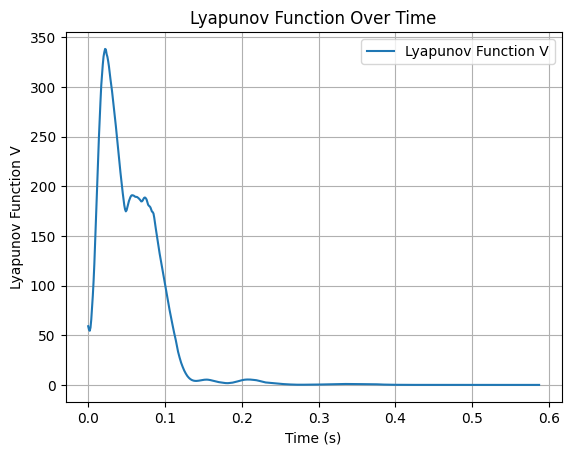

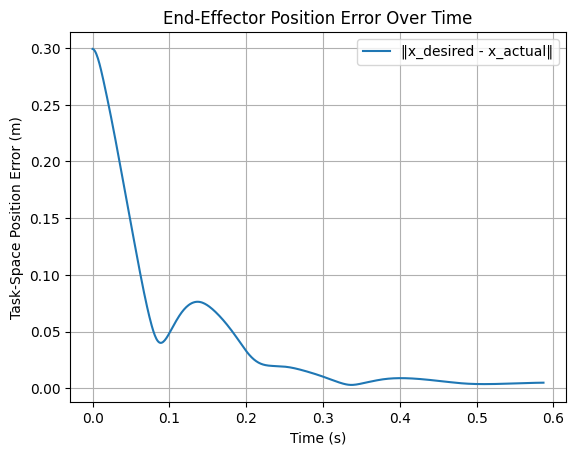

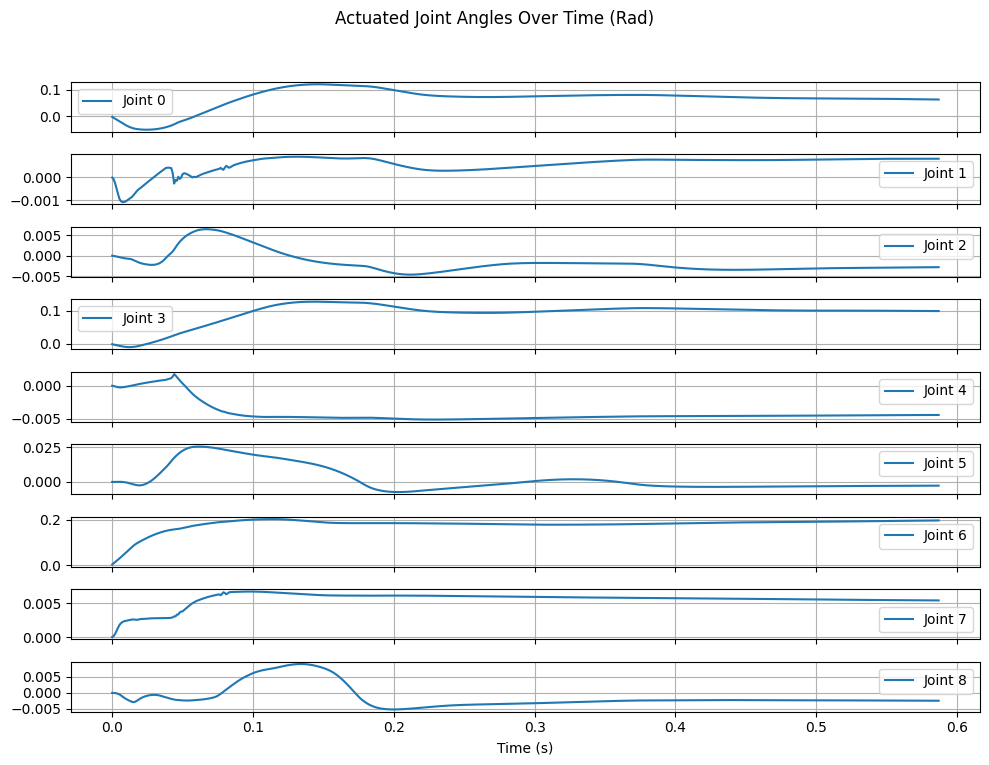

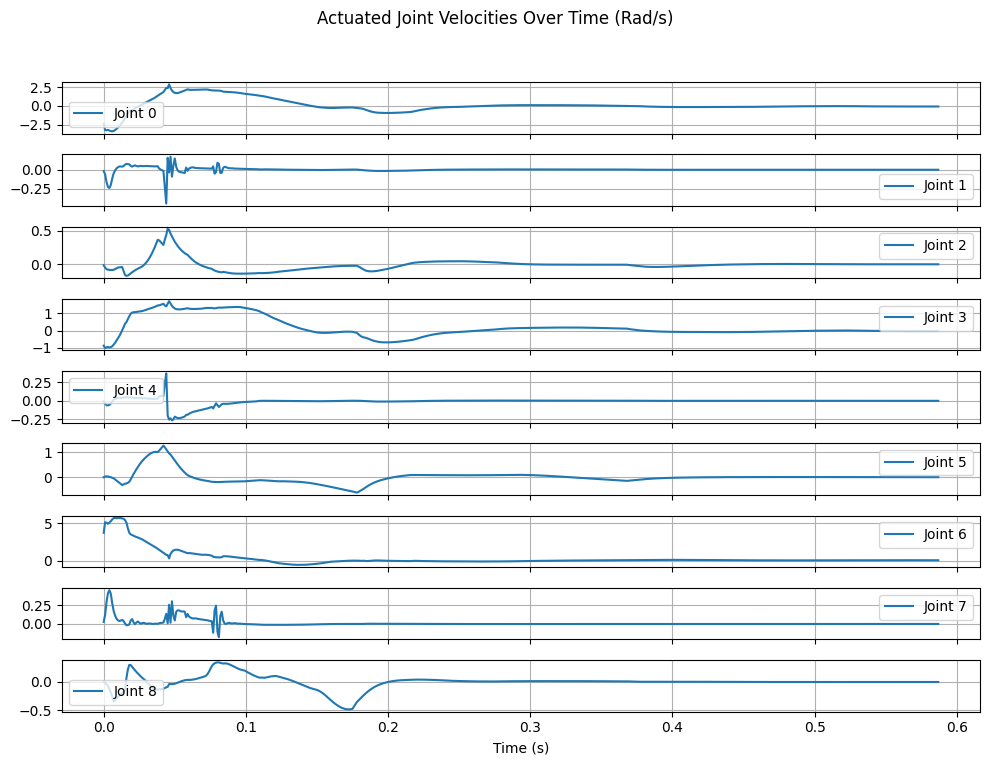

In [84]:

if __name__ == "__main__":
    # Simulate the model
    V_log, task_error_log, q_vel, q_pos, time_log, sim_ts = simulate_model()
    q_vel = np.array(q_vel)
    q_pos = np.array(q_pos)

    #Lyapunov Function Over Time – shows how stability evolves.
    plt.figure()
    plt.plot(time_log, V_log, label="Lyapunov Function V")
    plt.xlabel("Time (s)")
    plt.ylabel("Lyapunov Function V")
    plt.title("Lyapunov Function Over Time")
    plt.grid(True)
    plt.legend()  # <--- Add legend

    #End-Effector Position Error – checks task-space convergence.
    plt.figure()
    plt.plot(time_log, task_error_log, label="‖x_desired - x_actual‖")
    plt.xlabel("Time (s)")
    plt.ylabel("Task-Space Position Error (m)")
    plt.title("End-Effector Position Error Over Time")
    plt.grid(True)
    plt.legend()

    # Joint Angles (qq) 
    actuated_indices = np.where(np.any(B != 0, axis=0))[0]  # shape: (n_actuated,)
    fig, axs = plt.subplots(len(actuated_indices), 1, figsize=(10, 8), sharex=True)

    for i, idx in enumerate(actuated_indices):
        axs[i].plot(time_log, q_pos[:, idx], label=f"Joint {idx}")
        axs[i].legend()
        axs[i].grid(True)

    axs[-1].set_xlabel("Time (s)")
    fig.suptitle("Actuated Joint Angles Over Time (Rad)")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    # Joint Velocities (q̇) 
    actuated_indices = np.where(np.any(B != 0, axis=0))[0]  # shape: (n_actuated,)
    fig, axs = plt.subplots(len(actuated_indices), 1, figsize=(10, 8), sharex=True)

    for i, idx in enumerate(actuated_indices):
        axs[i].plot(time_log, q_vel[:, idx], label=f"Joint {idx}")
        axs[i].legend()
        axs[i].grid(True)

    axs[-1].set_xlabel("Time (s)")
    fig.suptitle("Actuated Joint Velocities Over Time (Rad/s)")
    fig.tight_layout(rect=[0, 0.03, 1, 0.95])

    # # Control inputs plot
    # actuated_indices = np.where(np.any(B != 0, axis=0))[0]  # shape: (n_actuated,)
    # ctrl = np.array(sim_ts["ctrl"])  # shape: (timesteps, nu)
    # num_actuators = ctrl.shape[1]
    # control_limit = 25

    # fig, axs = plt.subplots(actuated_indices, 1, figsize=(10, 8), sharex=True)

    # for i in range(actuated_indices):
    #     axs[i].plot(time_log, ctrl[:, i], label=f"Actuator {i}")
    #     axs[i].axhline(control_limit, color='r', linestyle='--', linewidth=1)
    #     axs[i].axhline(-control_limit, color='r', linestyle='--', linewidth=1)
    #     axs[i].set_ylabel("Torque (Nm)")
    #     axs[i].legend()
    #     axs[i].grid(True)

    # axs[-1].set_xlabel("Time (s)")
    # fig.suptitle("Control Inputs at Actuated Joints")
    # fig.tight_layout(rect=[0, 0.03, 1, 0.95])


